In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("mexwell/crop-diseases-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.00G/2.00G [00:26<00:00, 82.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1):
['Data']


In [ ]:
import os

# Update path to match 'Data' directory found in the crop diseases dataset
data_path = os.path.join(path, 'Data')

# List subdirectories in Data (usually class labels)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['train.csv', 'label_num_to_disease_map.json', 'train_images']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1/Data) ---
Found 17938 images. Displaying 6 samples:


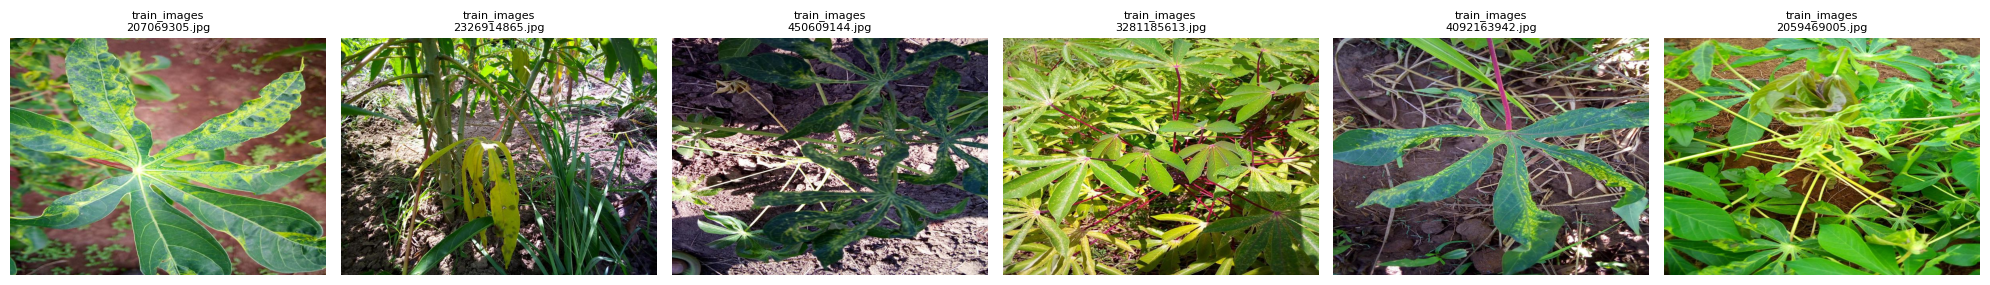

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct Data path
data_path = os.path.join(path, 'Data')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Paths to the CSV file and the image directory
csv_path = os.path.join(data_path, 'train.csv')
image_dir = os.path.join(data_path, 'train_images')

# Read data from CSV
df = pd.read_csv(csv_path)

# Split the dataset into 80% train and 20% test
# stratify=df['label'] ensures the proportion of crop disease classes is maintained in both sets
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Total samples in 'train_images': {len(df)}")
print(f"Number of training samples: {len(train_df)}")
print(f"Number of test samples: {len(test_df)}")

# Display the first few rows of the training set for verification
display(train_df.head())

Total samples in 'train_images': 21397
Number of training samples: 17117
Number of test samples: 4280


,image_id,label
1715,1300823152.jpg,4
11830,3116613979.jpg,3
8621,2530012971.jpg,3
3849,1686186154.jpg,3
12924,3312736716.jpg,1


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
import glob

class CropDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        # Create a mapping of filename to absolute path by searching all subdirectories
        print(f"Mapping image paths in {root_dir}... (this may take a moment)")
        self.image_path_map = {os.path.basename(p): p for p in glob.glob(os.path.join(root_dir, '**', '*.*'), recursive=True)}

        # Filter dataframe to only include images that exist on disk
        initial_count = len(dataframe)
        self.dataframe = dataframe[dataframe.iloc[:, 0].isin(self.image_path_map.keys())].copy()
        final_count = len(self.dataframe)

        print(f"Mapped {len(self.image_path_map)} files. Filtered dataset from {initial_count} to {final_count} samples.")
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx, 0]
        img_path = self.image_path_map[img_name]

        image = Image.open(img_path).convert('RGB')
        label = int(self.dataframe.iloc[idx, 1])

        if self.transform:
            image = self.transform(image)
        return image, label

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create Dataloaders using filtered datasets
train_dataset = CropDataset(train_df, data_path, transform=transform)
test_dataset = CropDataset(test_df, data_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Build DenseNet Model
model = models.densenet121(weights='IMAGENET1K_V1')
num_ftrs = model.classifier.in_features
num_classes = df['label'].nunique()
model.classifier = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
history = {'train_loss': [], 'test_acc': []}
epochs = 10

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    history['test_acc'].append(accuracy)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

Mapping image paths in /root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1/Data... (this may take a moment)
Mapped 17940 files. Filtered dataset from 17117 to 14342 samples.
Mapping image paths in /root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1/Data... (this may take a moment)
Mapped 17940 files. Filtered dataset from 4280 to 3596 samples.
Starting Training...
Epoch [1/10], Loss: 0.7454, Test Accuracy: 58.68%
Epoch [2/10], Loss: 0.5874, Test Accuracy: 78.45%
Epoch [3/10], Loss: 0.5188, Test Accuracy: 79.70%
Epoch [4/10], Loss: 0.4675, Test Accuracy: 76.11%
Epoch [5/10], Loss: 0.4349, Test Accuracy: 81.12%
Epoch [6/10], Loss: 0.3946, Test Accuracy: 81.28%
Epoch [7/10], Loss: 0.3618, Test Accuracy: 81.95%
Epoch [8/10], Loss: 0.3236, Test Accuracy: 76.92%
Epoch [9/10], Loss: 0.2935, Test Accuracy: 79.23%
Epoch [10/10], Loss: 0.2512, Test Accuracy: 81.12%


### Training Results Summary
The model was trained for 3 epochs using a pre-trained DenseNet121 architecture. The final test accuracy and loss trends indicate how well the model is learning to classify crop diseases based on the provided dataset.

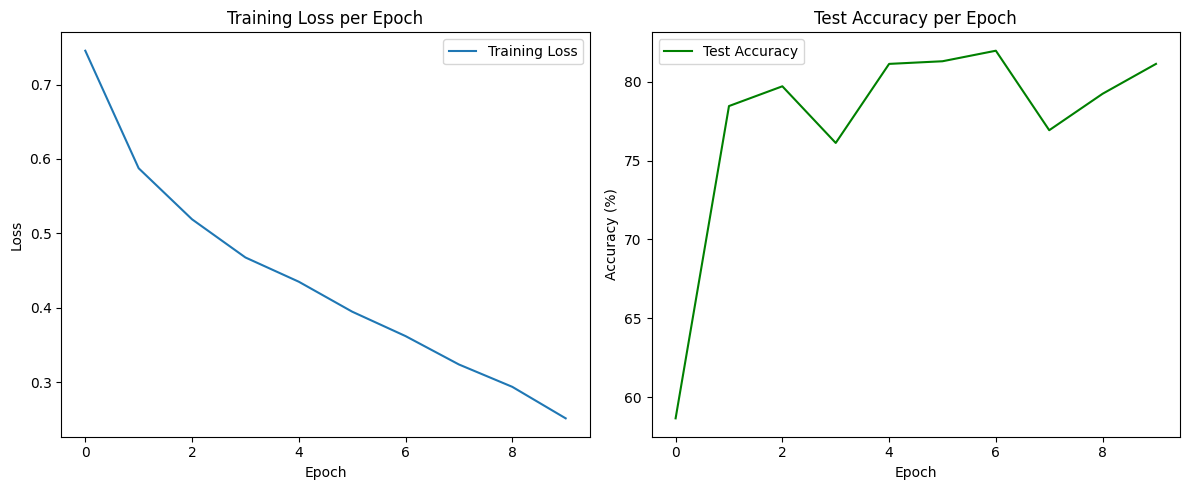

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['test_acc'], label='Test Accuracy', color='green')
plt.title('Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()